### Mahekdeep Kaur <br>  918042896
___
# Homework #3

## Due Date: Tuesday, January 7, 23:59

### Part 1: Neuronal Spike Train Analysis Using Poisson Processes

   A neuroscientist is studying the firing patterns of a certain type of neuron in the brain. The average firing rate of these neurons is found to be 5 spikes per second. Assuming that the spike train of these neurons can be modeled as a Poisson process:

   a) What is the probability that the neuron fires exactly 10 times in a 2-second interval?

   b) Calculate the probability that the neuron fires at least once within a 0.1-second interval.

   c) What is the expected value of spikes for a 2 second interval?

### Answer
Average firing rate, $ \lambda = 5 $ spikes per second. <br>
a)
For a 2-second interval, the mean number of spikes is: <br>
$ \mu = \lambda \cdot \text{time} = 5 \cdot 2 = 10 $ <br>
The probability mass function (PMF) of a Poisson process is given by: <br>
$ P(X = k) = \frac{e^{-\mu} \mu^k}{k!} $ <br>
Substituting $ \mu = 10 $ and $ k = 10 $: <br>
$ P(X = 10) = \frac{e^{-10} \cdot 10^{10}}{10!} $ <br> <br>

b)
For a 0.1-second interval, the mean number of spikes is: <br>
$ \mu = \lambda \cdot \text{time} = 5 \cdot 0.1 = 0.5 $ <br>
The probability of at least one spike is: <br>
$ P(X \geq 1) = 1 - P(X = 0) $ <br>
For $ P(X = 0) $, substitute $ k = 0 $ and $ \mu = 0.5 $: <br>
$ P(X = 0) = \frac{e^{-0.5} \cdot 0.5^0}{0!} = e^{-0.5} $ <br>
Thus: <br>
$ P(X \geq 1) = 1 - e^{-0.5} $ <br> <br>

c)
The expected value for a Poisson process is equal to the mean: <br>
$ E(X) = \mu = \lambda \cdot \text{time} = 5 \cdot 2 = 10 $ <br>


### Part 2: Programming a Poisson Process 

#### Notes:

- For all programming tasks, ensure that your code is well-commented to explain your logic and approach.
- Make sure to handle edge cases, such as negative values of $\lambda$ or $k$, appropriately in your functions.
- In Question 2, if you're unfamiliar with plotting libraries, focus on generating the probabilities and understanding the distribution's shape through the output values before attempting to plot.

#### Question 1: Implementing the Poisson Distribution

**Objective**: Write a program to manually calculate the probability of observing a given number of events $k$ in a fixed interval, given the average rate of occurrences $\lambda$, using the Poisson formula. You are not allowed to use any external libraries that directly compute Poisson probabilities.

**Instructions**:
1. Your program should define a function `poisson_probability(lambda, k)` that takes the average rate $\lambda$ and the desired number of occurrences $k$ as inputs.
2. The function should use the Poisson formula:
   $
   P(k; \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}
   $
3. Calculate $k!$ (factorial of $k$) using a loop or recursive function.
4. Return the probability of observing exactly $k$ events.
5. Test your function by calculating the probability of observing 3 events for $\lambda = 2.5$.

In [1]:
import math

# Function to calculate factorial using a loop
def factorial(n):
    if n == 0:
        return 1
    fact = 1
    for i in range(1, n + 1):
        fact *= i
    return fact

# Function to calculate Poisson probability
def poisson_probability(lmbda, k):
    if lmbda < 0 or k < 0:
        raise ValueError("Lambda (rate) and k (number of occurrences) must be non-negative.")
    
    # Using the Poisson formula
    probability = (lmbda ** k) * math.exp(-lmbda) / factorial(k)
    return probability

# Test the function with lambda = 2.5 and k = 3
lmbda = 2.5
k = 3
result = poisson_probability(lmbda, k)

# Display the result
print(f"The probability of observing {k} events for lambda = {lmbda} is {result}")

The probability of observing 3 events for lambda = 2.5 is 0.21376301724973645


### Question 2: Drawing a Poisson Distribution

**Objective**: Create a function to simulate and plot the Poisson distribution for a given $\lambda$ over a range of $k$ values (e.g., from 0 to 20). You may use basic plotting libraries (like matplotlib in Python) but should calculate the Poisson probabilities manually using your function from Question 1.

**Instructions**:
1. Define a function `plot_poisson_distribution(lambda, k_range)` where `lambda` is the average rate of events, and `k_range` is the maximum value of $k$ you want to plot.
2. Use your `poisson_probability` function to compute the probabilities for each $k$ from 0 to `k_range`.
3. Store the probabilities in a list or array.
4. Plot $k$ on the x-axis and the corresponding probabilities on the y-axis. Make sure to label your axes appropriately.
5. Test your plotting function with $\lambda = 4$ and `k_range = 15`.

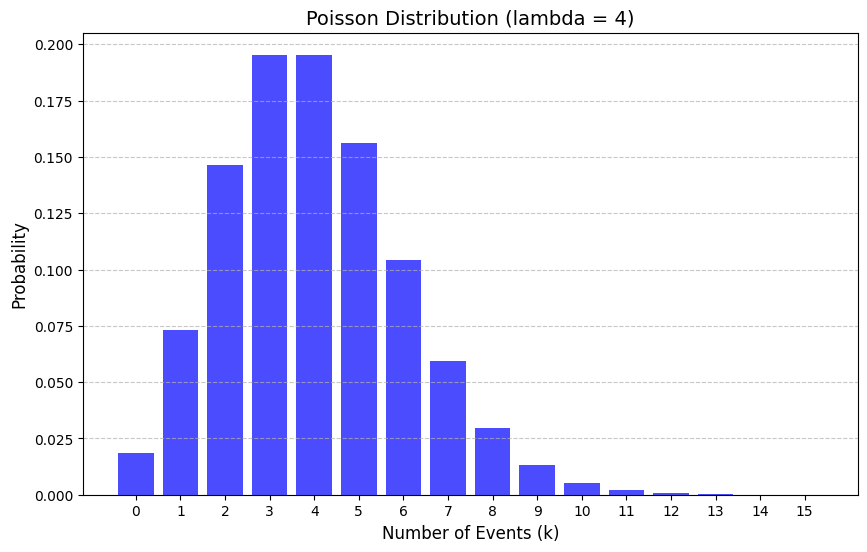

In [2]:
import matplotlib.pyplot as plt

# Function to calculate and plot the Poisson distribution
def plot_poisson_distribution(lmbda, k_range):
    # List to store probabilities
    probabilities = []
    
    # Calculate probabilities for each k from 0 to k_range
    for k in range(k_range + 1):
        prob = poisson_probability(lmbda, k)
        probabilities.append(prob)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(range(k_range + 1), probabilities, color='blue', alpha=0.7)
    plt.xlabel("Number of Events (k)", fontsize=12)
    plt.ylabel("Probability", fontsize=12)
    plt.title(f"Poisson Distribution (lambda = {lmbda})", fontsize=14)
    plt.xticks(range(k_range + 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Test the function with lambda = 4 and k_range = 15
lmbda = 4
k_range = 15
plot_poisson_distribution(lmbda, k_range)

### Question 3: Calculating the Cumulative Probability

**Objective**: Write a program to calculate the cumulative probability of observing up to $n$ events for a given $\lambda$, without using any external cumulative distribution function.

**Instructions**:
1. Your program should define a function `cumulative_poisson_probability(lambda, n)` that computes the cumulative probability of observing up to $n$ events.
2. The function should sum the probabilities of observing 0 up to $n$ events, using your `poisson_probability` function from Question 1.
3. Return the cumulative probability.
4. Test your function by calculating the cumulative probability of observing up to 5 events for $\lambda = 3$.

In [3]:
# Function to calculate cumulative Poisson probability
def cumulative_poisson_probability(lmbda, n):
    if lmbda < 0 or n < 0:
        raise ValueError("Lambda (rate) and n (number of events) must be non-negative.")
    
    # Initialize cumulative probability
    cumulative_prob = 0
    
    # Sum probabilities from k = 0 to n
    for k in range(n + 1):
        cumulative_prob += poisson_probability(lmbda, k)
    
    return cumulative_prob

# Test the function with lambda = 3 and n = 5
lmbda = 3
n = 5
result = cumulative_poisson_probability(lmbda, n)

# Display the result
print(f"The cumulative probability of observing up to {n} events for lambda = {lmbda} is {result}")

The cumulative probability of observing up to 5 events for lambda = 3 is 0.9160820579686966


### Question 4: Generating and Analyzing Spike Trains

**Objective**: Generate spike trains using a Poisson process and analyze their properties, incorporating a refractory period and exploring neuron burstiness and correlation.

**Instructions**:

#### 4.1: Generate a Poisson Spike Train
1. Use the Poisson process generator from last week to create a spike train.
2. Set the spike rate to $r_0 = 30$ spikes per second and simulate over 60 seconds.
3. Display the resulting spike train.

#### 4.2: Add a Refractory Period
1. Modify the Poisson process generator to include a refractory period parameter, set to 1 millisecond.
2. Simulate the refractory period as follows:
   - After each spike, set the firing rate to 0.
   - Allow the firing rate to recover linearly to $r_0$ with the recovery rate:
     $$
     r(t) = r_0\frac{t-t_{spike}}{5}
     $$
     where $t_{spike}$ is the time of the last spike, and both $t$ and $t_{spike}$ are in milliseconds.
   - Ensure $r(t)$ does not exceed the initial firing rate $r_0$.
3. Plot the resulting spike train overlaid with $r(t)$.

#### 4.3: Analyze the Spike Train
1. Generate the following plots for the spike train:
   - **1.3.1**: Time interval histogram (TIH).
   - **1.3.2**: Survivor function.
   - **1.3.3**: Hazard function.

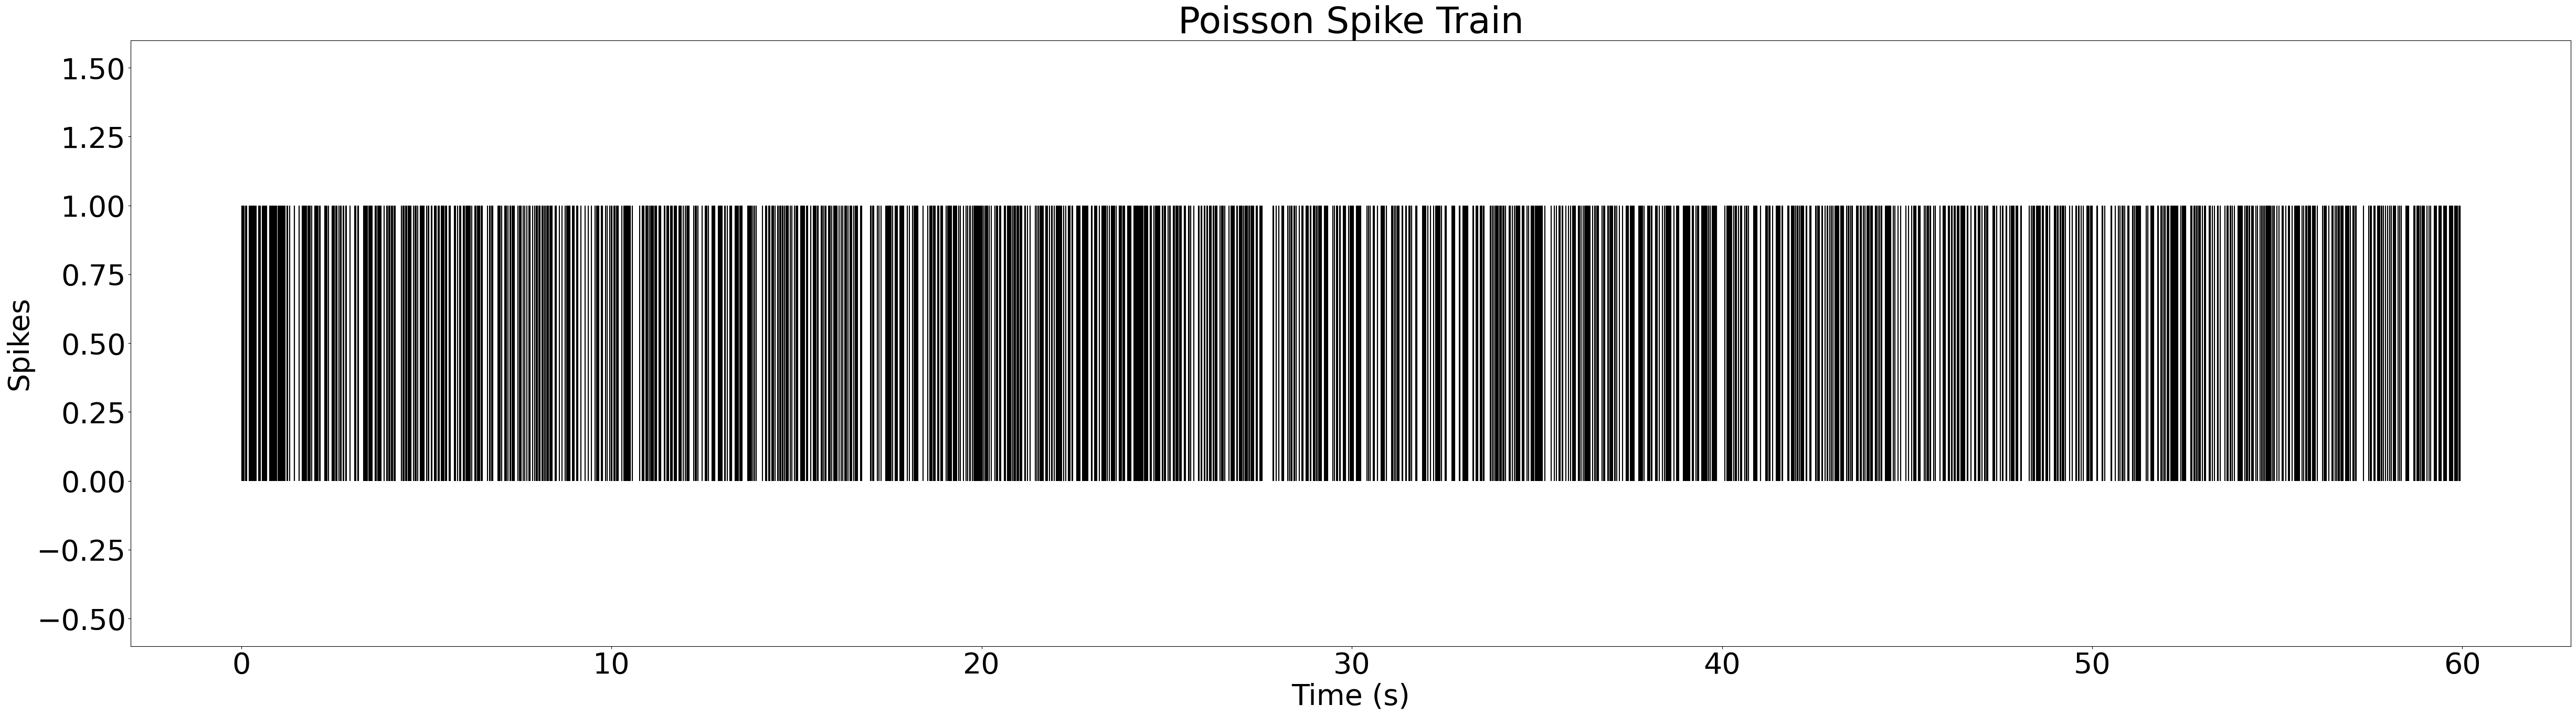

In [35]:
#4.1
import matplotlib.pyplot as plt
import numpy as np
from HW2_PoissonSpikeTrains import generatePoiSpikes

r0 = 30  
dt = 0.001  
T = 60000  

genSpikeTrain = generatePoiSpikes(r0, dt, T) # Function call to generate spikes

# plot spikes in seconds
plt.figure(figsize=(60,15))
plt.title("Poisson Spike Train", fontsize=50)
plt.eventplot(np.where(genSpikeTrain == 1)[0]*dt, color='black', lineoffsets=0.5) 
plt.xlabel("Time (s)", fontsize=40)
plt.ylabel("Spikes", fontsize=40)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.show()

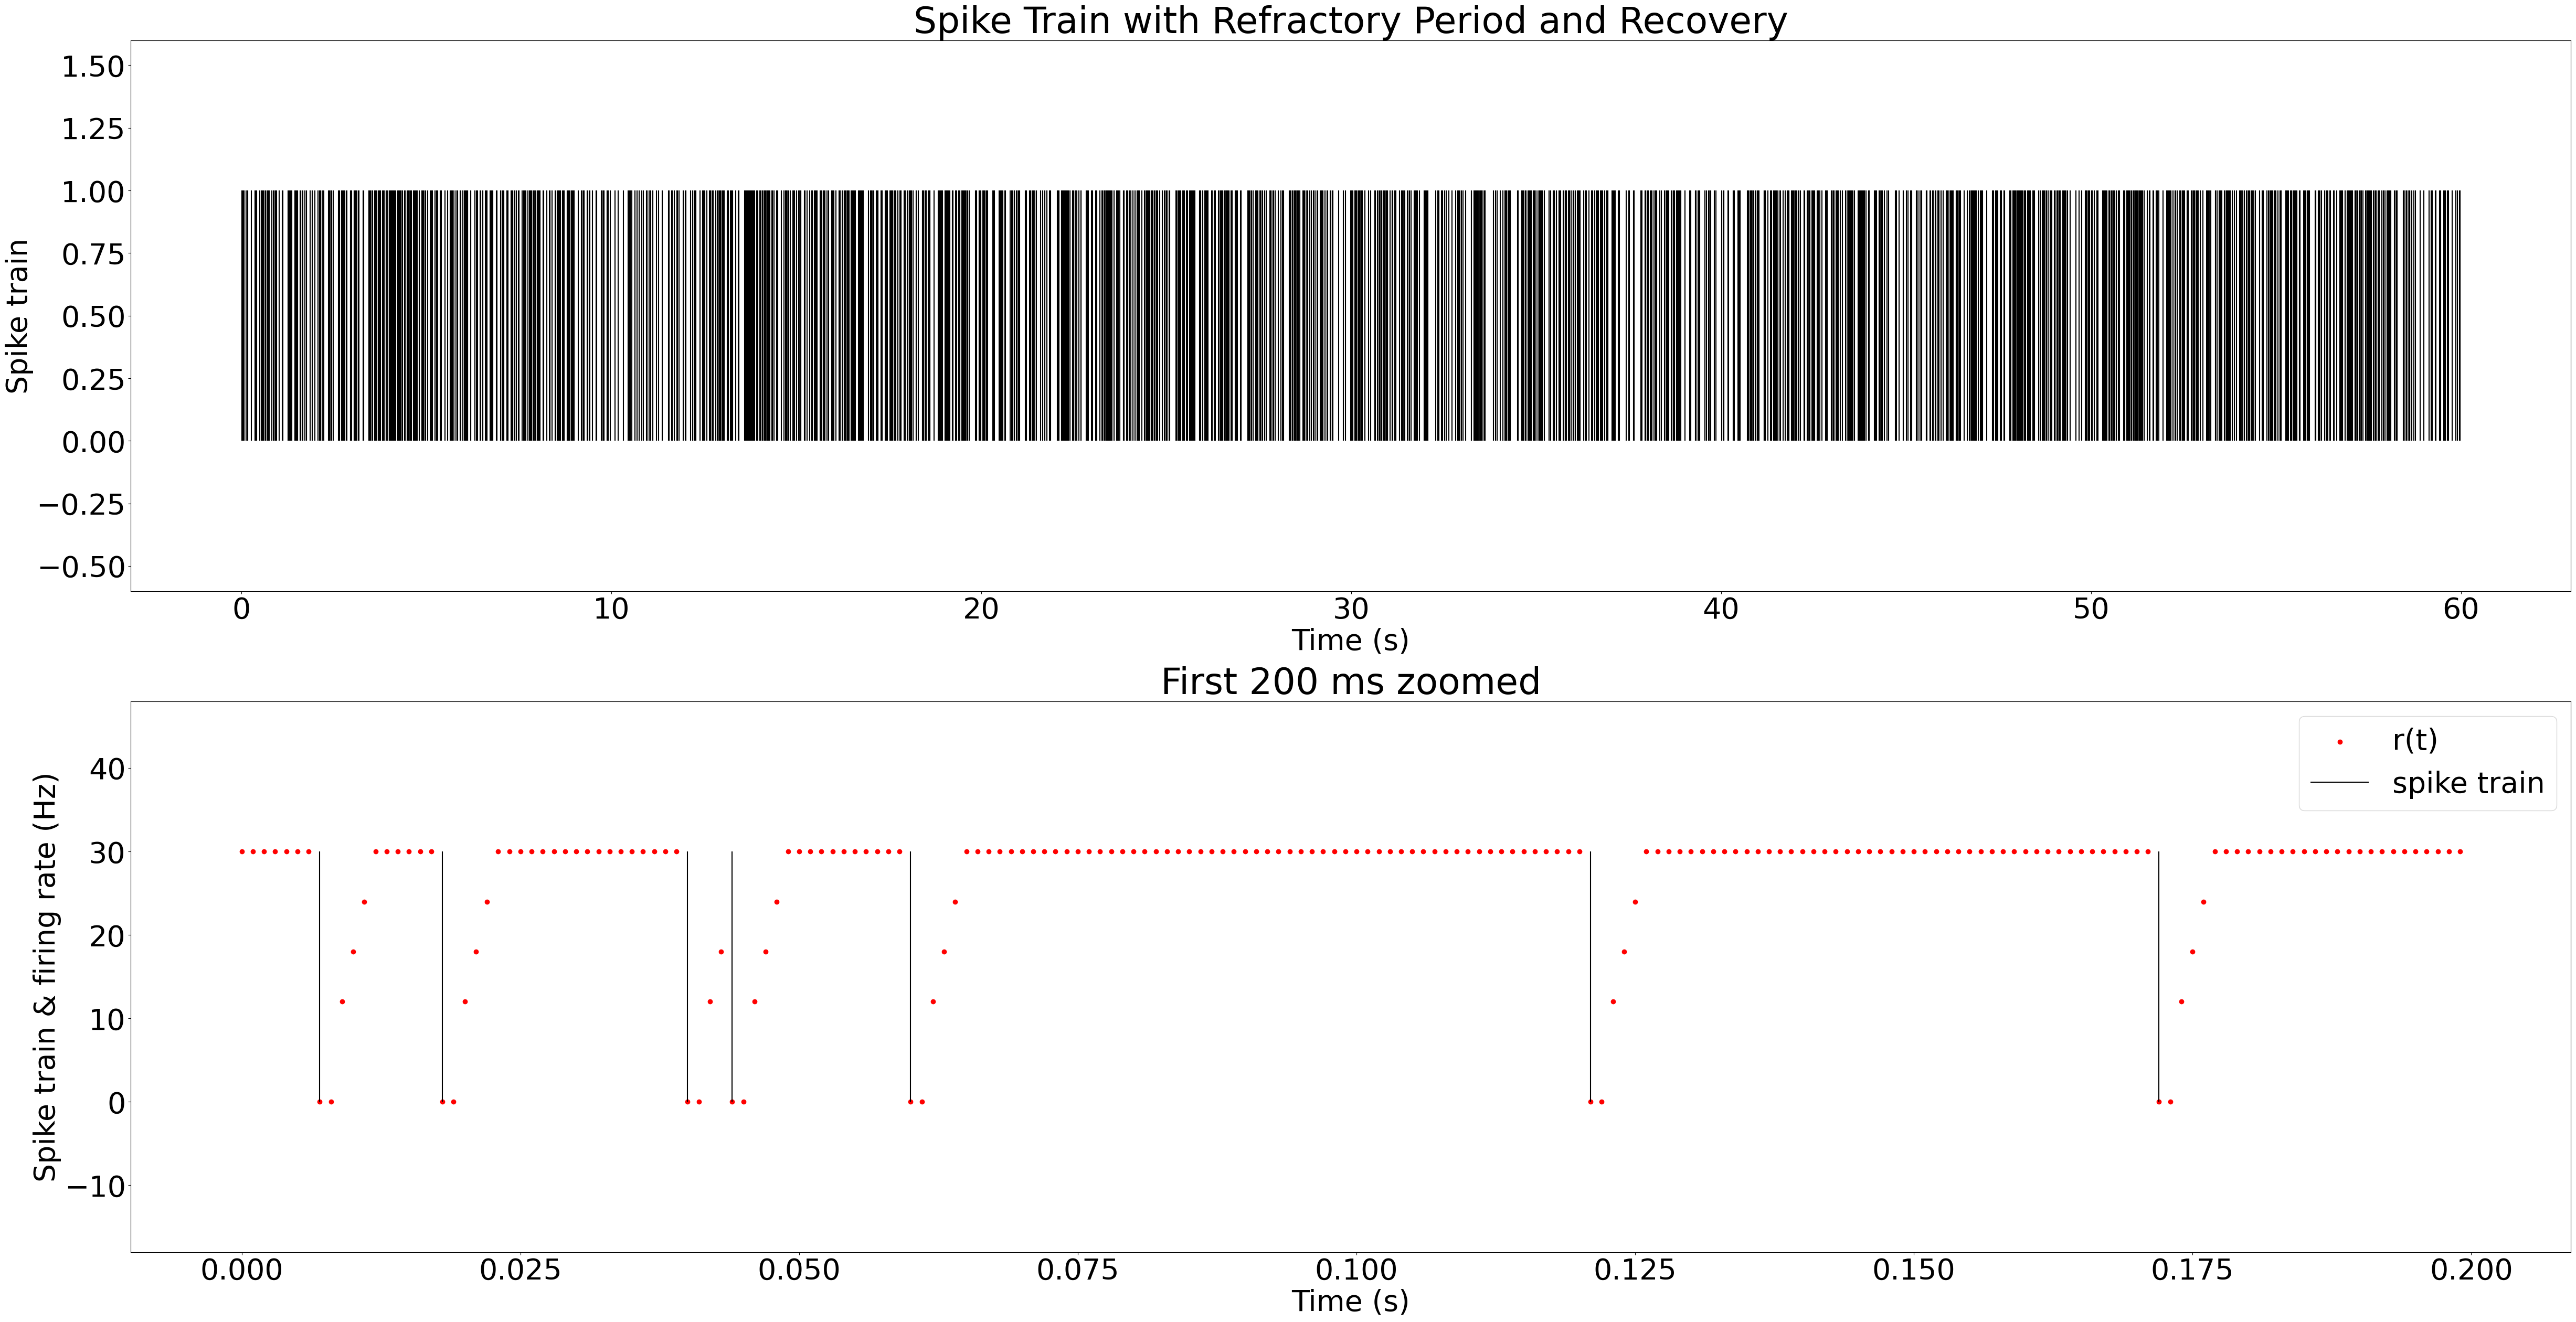

In [12]:
#4.2
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r0 = 30  # Initial firing rate (Hz)
T = 60  # Total simulation time in s
dt = 0.001  # Time step in s
refractory_period = 0.001  # Refractory period in s

# Function definition implementing refractory period in generation of Poisson spike train
def generatePoiSpikesRefractory(r, dt, T, ref_per):
    T = T*1000
    dt = dt*1000
    ref_per = ref_per*1000

    # Spike train and firing rate
    spike_train = np.zeros(T)
    firing_rate = np.ones(T)*r
    t_spike = None  # Time of the last spike

    # Generate spike train
    for i, t in enumerate(np.arange(0, T, dt)):
        if t_spike != None:
            if t - t_spike <= ref_per:  # Refractory period
                r_t = 0  # Firing rate is zero during refractory period
            else:
                r_t = r0 * ((t - t_spike) / 5)  # Recovery rate after spike
            firing_rate[i] = min(r_t, r0)  # Ensure recovery rate does not exceed r0

        # Generate a spike based on the current firing rate
        if np.random.rand() < (firing_rate[i] * dt / 1000):  # Convert rate to probability
            spike_train[i] = 1
            firing_rate[i] = 0
            t_spike = t  # Update the time of the last spike
    return spike_train, firing_rate

spike_train, firing_rate = generatePoiSpikesRefractory(r0, dt, T, refractory_period)

# Plot the spike train and recovery rate
window = 200
plt.figure(figsize=(60, 30))
plt.subplot(2, 1, 1)
plt.eventplot(np.where(spike_train == 1)[0]*dt, color='black', lineoffsets=0.5) 
plt.title("Spike Train with Refractory Period and Recovery", fontsize=50)
plt.xlabel("Time (s)", fontsize=40)
plt.ylabel("Spike train", fontsize=40)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40) 
plt.subplot(2, 1, 2)
plt.scatter(np.arange(window)*0.001, firing_rate[:window], color='red', label='r(t)')
plt.eventplot(np.where(spike_train[:window] == 1)[0]*dt, color='black', lineoffsets=r0/2, linelengths=r0, label='spike train')
plt.title(f"First {window} ms zoomed", fontsize=50)
plt.xlabel("Time (s)", fontsize=40)
plt.ylabel("Spike train & firing rate (Hz)", fontsize=40)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.legend(fontsize=40)
plt.show()

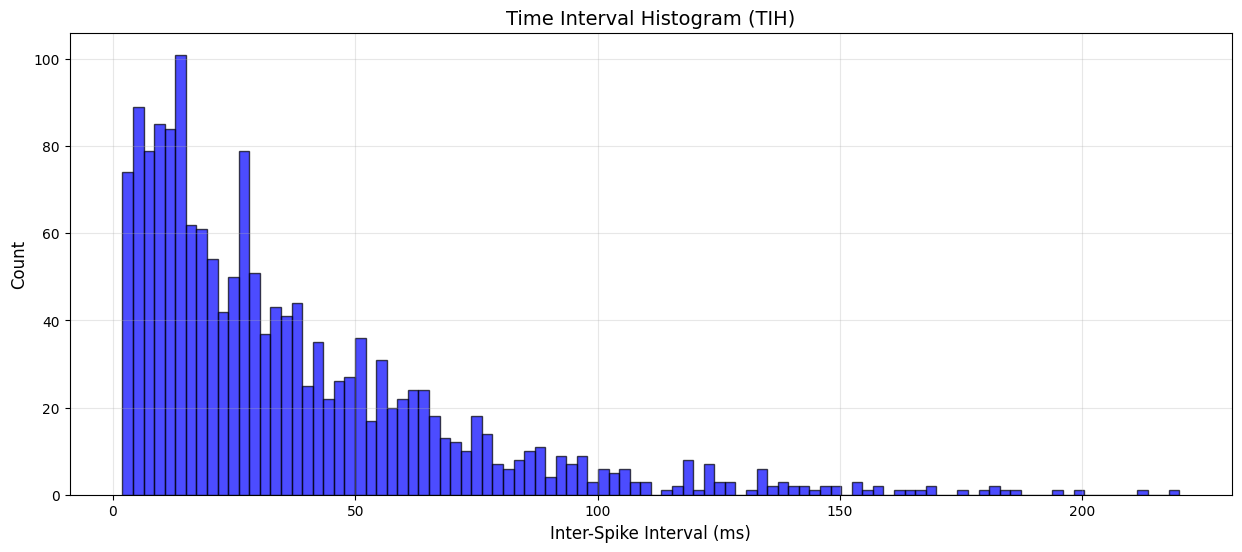

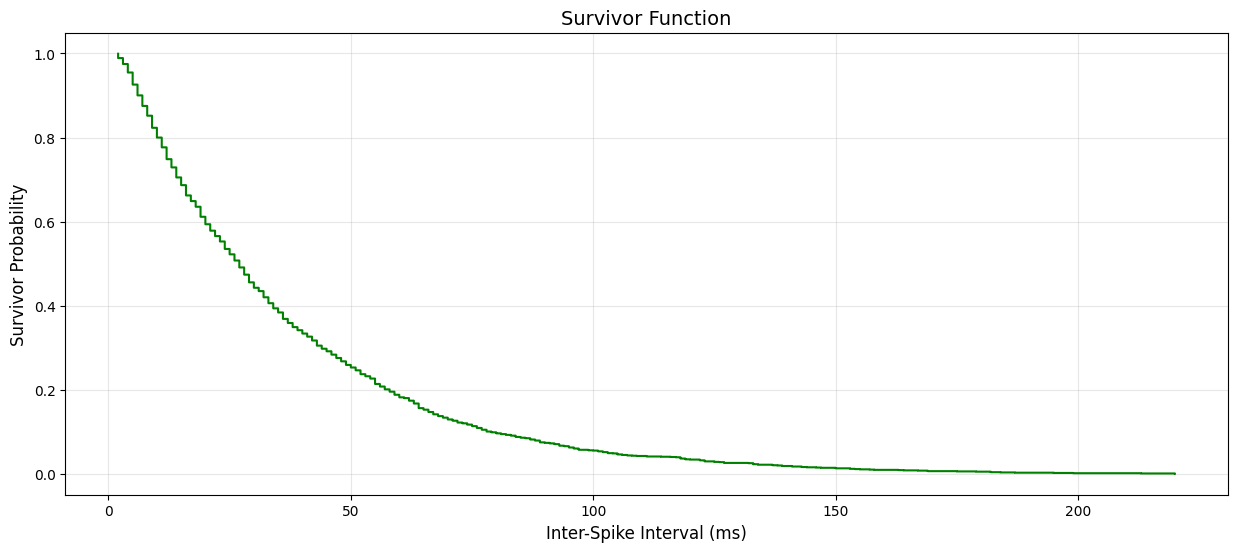

/var/folders/1l/x84gy9kx5n38_hkxyr0krz700000gn/T/ipykernel_38615/1823319012.py:33: RuntimeWarning: divide by zero encountered in divide
  hazard_prob = -np.gradient(survivor_prob)/(survivor_prob)  # Hazard probability


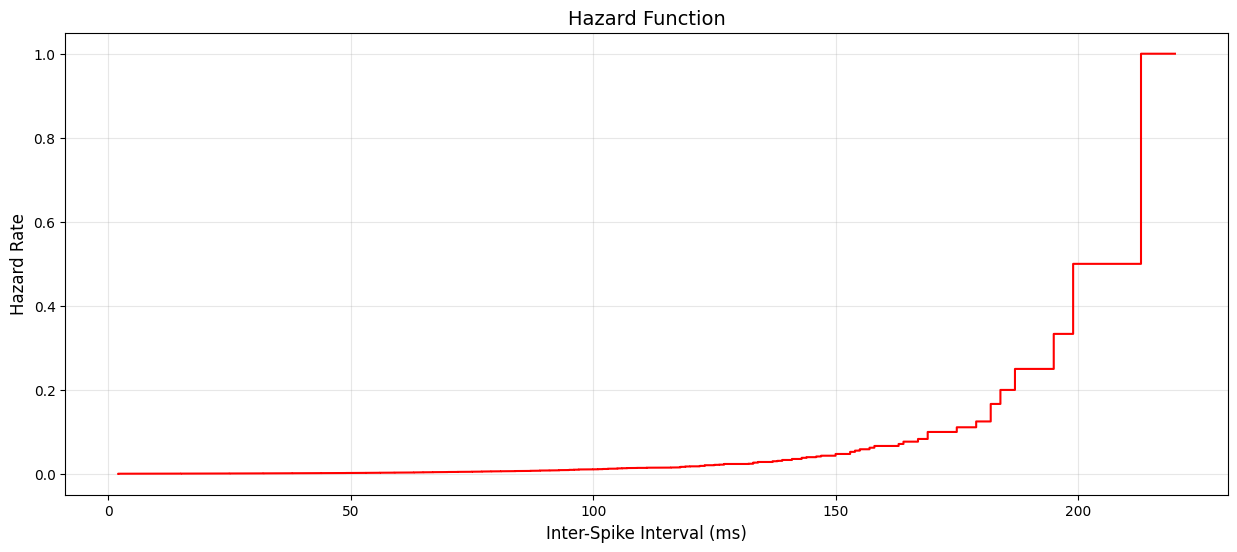

In [13]:
#4.3
#Compute and plot time interval histogram
def tih(spike_train):
    spike_times = np.where(spike_train == 1)[0]  # Spike times in seconds

    inter_spike_intervals = np.diff(spike_times)  # Time differences between consecutive spikes

    plt.figure(figsize=(15, 6))
    plt.hist(inter_spike_intervals, bins=100, color='blue', edgecolor='black', alpha=0.7)
    plt.title("Time Interval Histogram (TIH)", fontsize=14)
    plt.xlabel("Inter-Spike Interval (ms)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()
    return inter_spike_intervals

#Compute and plot the survivor function
def survivor_function(inter_spike_intervals):
    sorted_isi = np.sort(inter_spike_intervals)  # Sort ISIs
    survivor_prob = 1 - np.arange(1, len(sorted_isi) + 1) / len(sorted_isi)  # Survival probability

    plt.figure(figsize=(15, 6))
    plt.step(sorted_isi, survivor_prob, where='post', color='green')
    plt.title("Survivor Function", fontsize=14)
    plt.xlabel("Inter-Spike Interval (ms)", fontsize=12)
    plt.ylabel("Survivor Probability", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()
    return sorted_isi, survivor_prob

#Compute and plot the hazard function
def hazard_function(sorted_isi, survivor_prob):
    hazard_prob = -np.gradient(survivor_prob)/(survivor_prob)  # Hazard probability

    plt.figure(figsize=(15, 6))
    plt.step(sorted_isi, hazard_prob, where='post', color='red')
    plt.title("Hazard Function", fontsize=14)
    plt.xlabel("Inter-Spike Interval (ms)", fontsize=12)
    plt.ylabel("Hazard Rate", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

#Function calls
isi = tih(spike_train)
sorted_isi, survivor_prob = survivor_function(isi)
hazard_function(sorted_isi, survivor_prob)

### Question 5: Exploring Neuronal Burstiness and Correlation

**Objective**: Extend the spike generator to model bursty neurons and analyze correlations between oscillating neurons.

#### 5.1: Simulate Bursty Neuron Activity
1. Adapt the spike generator to model a **bursty** neuron.
2. Ensure the refractory period mechanism remains intact.
3. Plot the resulting spike train for the bursty neuron.

#### 5.2: Auto-Correlation of Spike Train
1. Refactor your homemade convolution function into a correlation function.
2. Auto-correlate the spike train with itself using this function.
3. Normalize the correlation by the amplitude of the center peak and interpret its meaning.

#### 5.3: Cross-Correlation of Two Oscillating Neurons
1. Generate two oscillating neurons by first defining their $r(t)$ and then randomizing the spike train accordingly.
2. Compute the cross-correlation of the two neurons using the correlation function.
3. Interpret the result:
   - Explain the time lag (x-axis) of the peaks.
   - Describe the amplitude (y-axis) of the peaks.

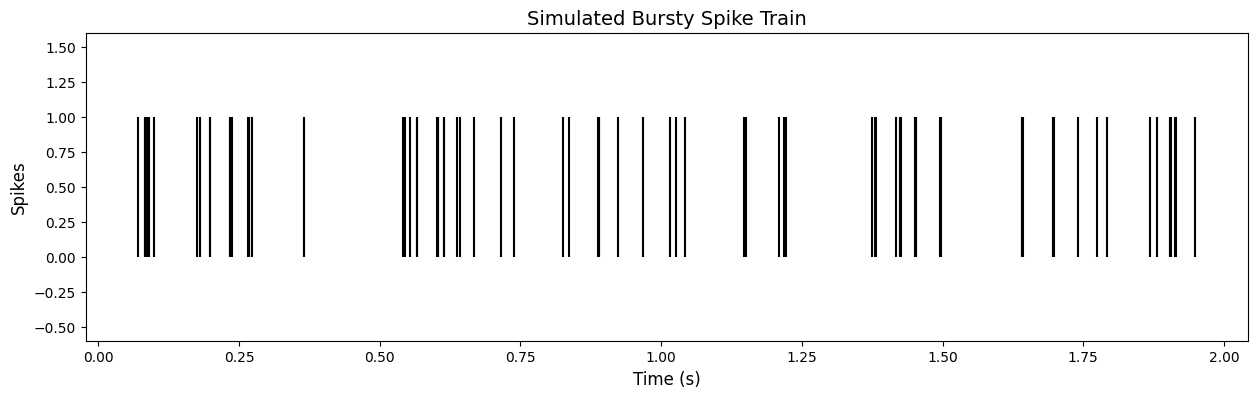

In [31]:
#5.1
import numpy as np
import matplotlib.pyplot as plt

def simulate_bursty_spike_train_with_refractory(duration, dt, r_0, refractory_period, burst_probability):
    duration = duration*1000
    dt = dt*1000
    refractory_period = refractory_period*1000
    
    t = np.arange(0, duration, dt)  # Time vector
    spike_train = np.zeros_like(t)  # Initialize spike train
    last_spike_time = -np.inf       # Keep track of the last spike time

    for i, time in enumerate(t):
        # Compute r(t) based on the refractory period
        time_since_spike = time - last_spike_time
        if time_since_spike <= refractory_period:
            r_t = 0
        else:
            r_t = r_0 * (time_since_spike / 5)  # Linear recovery

        # Limit r_t to base firing rate
        r_t = min(r_t, r_0)

        # Simulate Poisson process for spike generation
        if np.random.rand() < r_t * dt / 1000:
            spike_train[i] = 1
            last_spike_time = time

            # Randomly decide if a burst should occur
            if np.random.rand() < burst_probability:
                # Generate burst spikes
                burst_spike_count = np.random.randint(2, 5)  # Number of spikes in the burst
                burst_intervals = np.random.uniform(0, refractory_period, burst_spike_count)
                burst_times = time + np.cumsum(burst_intervals)  # Generate burst spike times
                for burst_time in burst_times:
                    burst_idx = int(burst_time / dt)
                    if burst_idx < len(spike_train):
                        spike_train[burst_idx] = 1
                        last_spike_time = burst_time  # Reset refractory mechanism

    return t, spike_train

# Simulate bursty spike train
t, spike_train = simulate_bursty_spike_train_with_refractory(2, 0.001, 30, 0.001, 0.5)

# Plot the spike train using event plot
spike_times = t[spike_train == 1]
plt.figure(figsize=(15, 4))
plt.eventplot(spike_times*dt, lineoffsets=0.5, colors='black')
plt.title('Simulated Bursty Spike Train', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Spikes', fontsize=12)
plt.show()

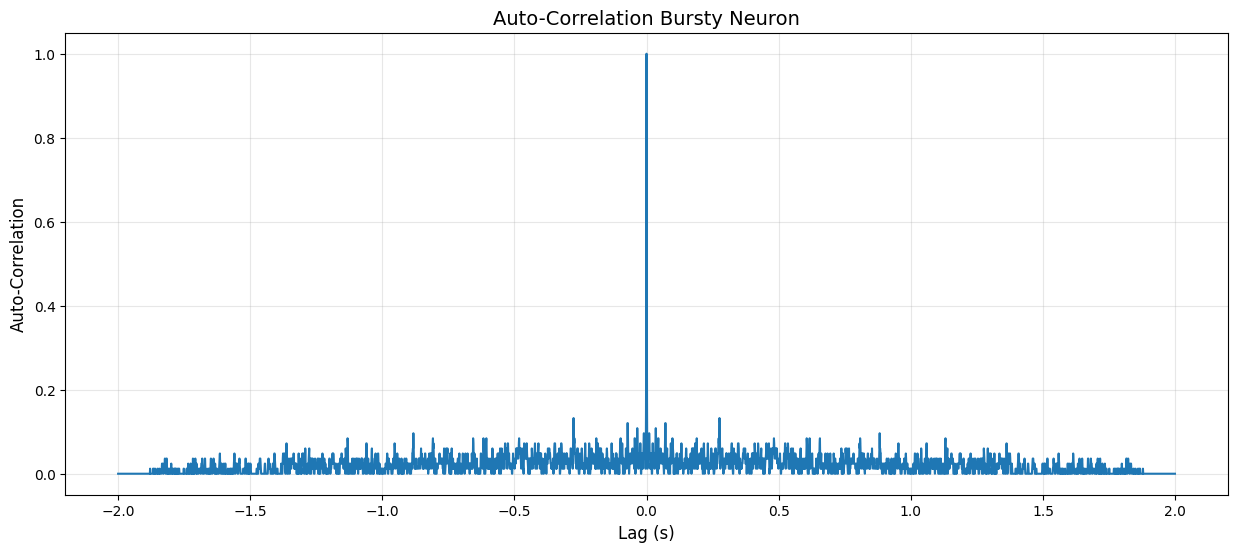

In [32]:
#5.2
def correlation(spikeTrain1, spikeTrain2):
    st1 = len(spikeTrain1)  
    st2 = len(spikeTrain2)
    
    corr = np.zeros(st1+st2-1)
    
    # Compute correlation
    for i in range(st1):
        for j in range(st2):
            corr[(i-j)+(st2-1)] += spikeTrain1[i]*spikeTrain2[j]
            
    return max(st1, st2), corr

# Auto-correlation of the spike train
length, auto_corr = correlation(spike_train, spike_train)
lags = np.arange(-length + 1, length) * dt

plt.figure(figsize=(15, 6))
plt.plot(lags, auto_corr/np.max(auto_corr))
plt.title('Auto-Correlation Bursty Neuron', fontsize=14)
plt.xlabel('Lag (s)', fontsize=12)
plt.ylabel('Auto-Correlation', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Normalization ensures that the autocorrelation is comparable across different spike trains, regardless of their total spike count or firing rate. This allows for meaningful analysis of the temporal structure without being biased by the scale of the original signal.

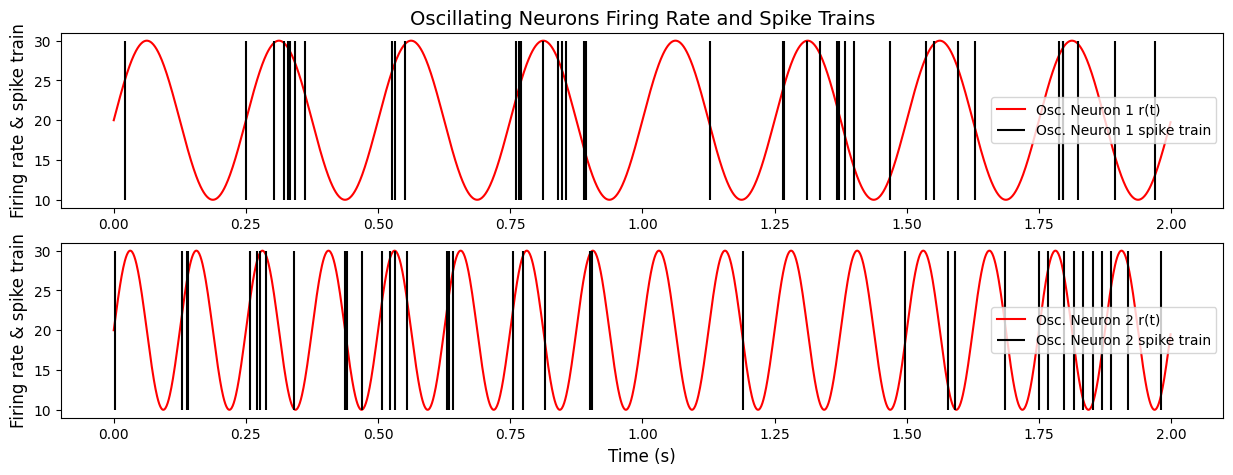

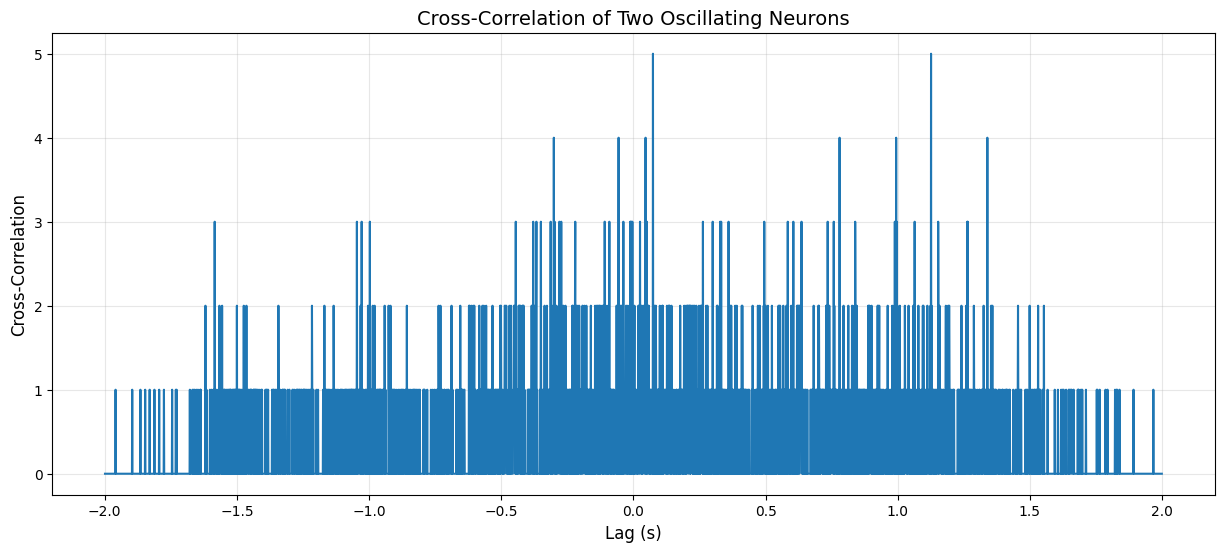

In [33]:
#5.3
def genOscPoissonSpikeTrain(duration, dt, base_rate, modulation_frequency, modulation_amplitude):
    time = np.arange(0, duration, dt)

    # Calculate oscillating firing rate (in Hz)
    oscillating_rate = base_rate + modulation_amplitude * np.sin(2 * np.pi * modulation_frequency * time)
    oscillating_rate[oscillating_rate < 0] = 0  # Ensure non-negative rate

    # Simulate Poisson spikes
    spike_train = np.random.rand(len(time)) < (oscillating_rate * dt)

    return time, spike_train, oscillating_rate

# Simulate oscillatory spike train
dur = 2
dt = 0.001
r0 = 20
amp = 10
f1 = 4
f2 = 8
time1, spike_train1, oscRate1 = genOscPoissonSpikeTrain(dur, dt, r0, f1, amp)
time2, spike_train2, oscRate2 = genOscPoissonSpikeTrain(dur, dt, r0, f2, amp)

plt.figure(figsize=(15, 5))
plt.subplot(2,1,1)
plt.plot(time1, oscRate1, label="Osc. Neuron 1 r(t)", color='red')
plt.eventplot(time1[spike_train1], lineoffsets=r0, linelength=2*amp,  colors='black', label="Osc. Neuron 1 spike train")
plt.title('Oscillating Neurons Firing Rate and Spike Trains', fontsize=14)
plt.ylabel('Firing rate & spike train', fontsize=12)
plt.legend()
plt.subplot(2,1,2)
plt.plot(time2, oscRate2, label="Osc. Neuron 2 r(t)", color = 'red')
plt.eventplot(time2[spike_train2], lineoffsets=r0, linelength=2*amp,  colors='black', label="Osc. Neuron 2 spike train")
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Firing rate & spike train', fontsize=12)
plt.legend()
plt.show()

# Cross-correlation of two oscillating neurons
length, cross_corr = correlation(spike_train1, spike_train2)
lags = np.arange(-length + 1, length) * dt
plt.figure(figsize=(15, 6))
plt.plot(lags, cross_corr)
plt.title('Cross-Correlation of Two Oscillating Neurons', fontsize=14)
plt.xlabel('Lag (s)', fontsize=12)
plt.ylabel('Cross-Correlation', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

**Time Lag (x-axis of the peaks):**

The time lag of the peaks in the cross-correlation represents the relative timing between the spikes of the two oscillating neurons. Specifically:
- **Positive Lag**: Indicates that the spikes of neuron 1 lead (precede) the spikes of neuron 2 by the given time interval.
- **Negative Lag**: Indicates that the spikes of neuron 2 lead (precede) the spikes of neuron 1 by the given time interval.
- **Zero Lag**: A peak at zero lag indicates that the two neurons fire synchronously or have a high degree of temporal alignment in their spike trains.

**Amplitude (y-axis of the peaks):**

The amplitude of the peaks reflects the strength of the correlation between the two spike trains at the corresponding time lag:
- **High Amplitude**: Indicates strong similarity or alignment between the two spike trains at a given lag, which could signify synchronous or phase-locked oscillatory activity.
- **Low Amplitude**: Suggests weak or no correlation between the spike trains at the given lag, which may indicate independent or asynchronous firing.